In [2]:
AUDIO_FILE = "lab3sample.wav"

import os

if not os.path.exists(AUDIO_FILE):
    raise FileNotFoundError(f"⚠️ Audio file not found: {AUDIO_FILE}\nPlease check the path.")
else:
    print(f"🎧 Using audio file: {AUDIO_FILE}")

from IPython.display import Audio, display

print("Playing the best reconstructed signal:")
display(Audio(AUDIO_FILE))


🎧 Using audio file: lab3sample.wav
Playing the best reconstructed signal:


In [3]:
import sounddevice as sd
import soundfile as sf

def record(filename="mic.wav", duration=4, sr=16000):
    print("🎙️ Speak now...")
    rec = sd.rec(int(duration * sr), samplerate=sr, channels=1)
    sd.wait()
    sf.write(filename, rec, sr)
    print(f"✅ Saved recording as: {filename}")

# Record clean speech
record("clean_speech.wav", duration=4)


🎙️ Speak now...
✅ Saved recording as: clean_speech.wav


In [13]:
import numpy as np
import soundfile as sf

def add_noise(input_file, output_file, noise_factor=0.02):
    y, sr = sf.read(input_file)
    noise = np.random.randn(len(y))
    y_noisy = y + noise_factor * noise
    y_noisy = np.clip(y_noisy, -1.0, 1.0)
    sf.write(output_file, y_noisy, sr)
    print(f"✅ Noisy version saved as: {output_file}")

add_noise("lab3sample.wav", "noisy_speech.wav", noise_factor=0.02)


✅ Noisy version saved as: noisy_speech.wav


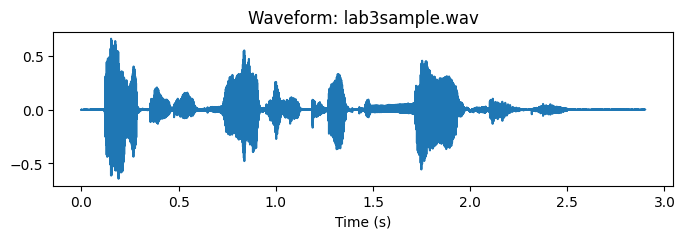

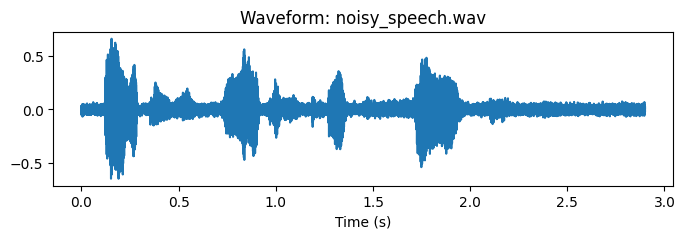

In [14]:
import librosa
import matplotlib.pyplot as plt

def plot_waveform(path):
    y, sr = librosa.load(path, sr=None)
    t = np.arange(len(y)) / sr
    plt.figure(figsize=(8, 2))
    plt.plot(t, y)
    plt.title(f"Waveform: {path}")
    plt.xlabel("Time (s)")
    plt.show()

plot_waveform("lab3sample.wav")
plot_waveform("noisy_speech.wav")


In [16]:
import whisper

try:
    print("Loading Whisper model (base)...")
    whisper_model = whisper.load_model("base")
    print("✅ Whisper model loaded successfully.")
except Exception as e:
    print(f"❌ Error loading Whisper model: {e}")

def transcribe_with_whisper(file_path):
    print(f"🎧 Recognizing with Whisper: {file_path}")
    try:
        result = whisper_model.transcribe(file_path)
        text = result.get("text", "").strip()
        if text:
            print("✅ Whisper transcription successful!")
        else:
            print("⚠️ Whisper could not understand the audio.")
        return text
    except Exception as e:
        print(f"❌ Error in Whisper transcription: {e}")
        return ""


Loading Whisper model (base)...
✅ Whisper model loaded successfully.


In [17]:
import speech_recognition as sr

recognizer = sr.Recognizer()

def transcribe_with_google(file_path):
    print(f"🌐 Recognizing with Google Speech API: {file_path}")
    try:
        with sr.AudioFile(file_path) as source:
            audio = recognizer.record(source)
        text = recognizer.recognize_google(audio)
        print("✅ Google transcription successful!")
        return text
    except sr.UnknownValueError:
        print("⚠️ Google could not understand audio.")
        return ""
    except sr.RequestError:
        print("❌ Google API request failed. Check internet connection.")
        return ""
    except Exception as e:
        print(f"❌ Error during Google transcription: {e}")
        return ""


In [18]:
# Clean speech
whisper_clean = transcribe_with_whisper("lab3sample.wav")
google_clean = transcribe_with_google("lab3sample.wav")

# Noisy speech
whisper_noisy = transcribe_with_whisper("noisy_speech.wav")
google_noisy = transcribe_with_google("noisy_speech.wav")


🎧 Recognizing with Whisper: lab3sample.wav


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


✅ Whisper transcription successful!
🌐 Recognizing with Google Speech API: lab3sample.wav
✅ Google transcription successful!
🎧 Recognizing with Whisper: noisy_speech.wav


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


✅ Whisper transcription successful!
🌐 Recognizing with Google Speech API: noisy_speech.wav
✅ Google transcription successful!


In [19]:
def compare_transcripts(whisper_text, google_text, label="Audio"):
    print(f"\n======= SPEECH-TO-TEXT COMPARISON ({label}) =======")
    print(f"Whisper: {whisper_text if whisper_text else '[No output]'}")
    print(f"Google:  {google_text if google_text else '[No output]'}")
    print("===============================================")

compare_transcripts(whisper_clean, google_clean, label="CLEAN")
compare_transcripts(whisper_noisy, google_noisy, label="NOISY")



======= SPEECH-TO-TEXT COMPARISON (CLEAN) =======
Whisper: I believe you're just talking nonsense.
Google:  I believe you are just talking nonsense

======= SPEECH-TO-TEXT COMPARISON (NOISY) =======
Whisper: I believe you're just talking nonsense.
Google:  I believe you are just talking nonsense


In [20]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def compute_tfidf_similarity(transcripts, names, reference_text, show_heatmap=True, cmap='viridis'):
    corpus = [reference_text] + transcripts
    labels = ["GroundTruth"] + names

    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)
    sim_matrix = cosine_similarity(X)
    df = pd.DataFrame(sim_matrix, index=labels, columns=labels)

    print("\nTF-IDF Cosine Similarity Matrix:")
    print(df.round(4))

    if show_heatmap:
        plt.figure(figsize=(6,5))
        im = plt.imshow(sim_matrix, vmin=0, vmax=1, cmap=cmap)
        plt.title("TF-IDF Cosine Similarity")
        plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(range(len(labels)), labels)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        for i in range(sim_matrix.shape[0]):
            for j in range(sim_matrix.shape[1]):
                plt.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                         fontsize=9, color='white' if sim_matrix[i,j] < 0.5 else 'black')
        plt.tight_layout()
        plt.show()

    return sim_matrix, df



TF-IDF Cosine Similarity Matrix:
                 GroundTruth  Whisper (Clean)  Google (Clean)  \
GroundTruth              1.0           0.0000          0.0000   
Whisper (Clean)          0.0           1.0000          0.7091   
Google (Clean)           0.0           0.7091          1.0000   
Whisper (Noisy)          0.0           1.0000          0.7091   
Google (Noisy)           0.0           0.7091          1.0000   

                 Whisper (Noisy)  Google (Noisy)  
GroundTruth               0.0000          0.0000  
Whisper (Clean)           1.0000          0.7091  
Google (Clean)            0.7091          1.0000  
Whisper (Noisy)           1.0000          0.7091  
Google (Noisy)            0.7091          1.0000  


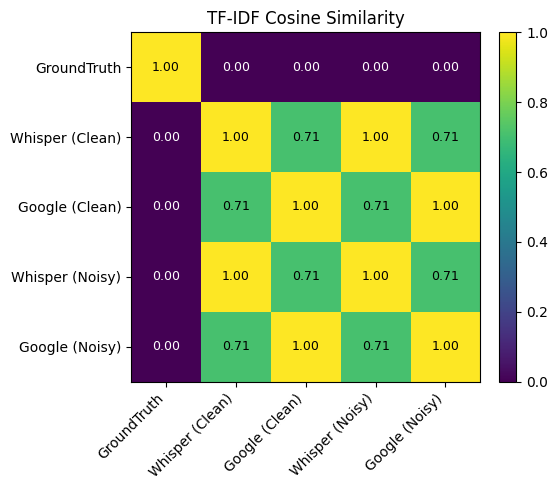

In [21]:
reference_text = input("👉 Enter the exact ground-truth/reference text: ")

sim_matrix, sim_df = compute_tfidf_similarity(
    transcripts=[whisper_clean, google_clean, whisper_noisy, google_noisy],
    names=["Whisper (Clean)", "Google (Clean)", "Whisper (Noisy)", "Google (Noisy)"],
    reference_text=reference_text,
    show_heatmap=True
)
